# AI-Powered Plastic Sorting MVP - Part 2: Model Training

**Objective**: Build and train a CNN classifier using transfer learning

**Approach**:
- Use ResNet50 pre-trained on ImageNet
- Fine-tune for plastic classification
- Target: 80-85% accuracy

---

## 1️⃣ Setup & Load Data

In [2]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import shutil
from datetime import datetime

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Check GPU
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure GPU memory growth (prevents OOM errors)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Load metadata from Part 1
df = pd.read_csv('plastic_metadata.csv')
print(f"📊 Loaded {len(df):,} images")
print(f"\nClass distribution:")
print(df['category'].value_counts())

📊 Loaded 3,164 images

Class distribution:
category
PET       594
PS        527
Others    526
PP        514
PE        511
PC        492
Name: count, dtype: int64


## 2️⃣ Handle Class Imbalance

We'll use two strategies:
1. **Class weights** during training (penalize errors on minority classes more)
2. **Data augmentation** to artificially balance classes

In [5]:
# Calculate class weights
# This tells the model to pay more attention to underrepresented classes

from collections import Counter

class_counts = df['category'].value_counts()
categories = sorted(df['category'].unique())

# Compute weights inversely proportional to class frequencies
total = len(df)
class_weights = {}

for i, cat in enumerate(categories):
    count = class_counts[cat]
    weight = total / (len(categories) * count)
    class_weights[i] = weight

print("⚖️  Class Weights (higher = more important):")
for i, cat in enumerate(categories):
    print(f"  {cat:10s}: {class_weights[i]:.3f}")

# Save class mapping
class_mapping = {i: cat for i, cat in enumerate(categories)}
with open('class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)

print("\n💾 Saved class_mapping.json")

⚖️  Class Weights (higher = more important):
  Others    : 1.003
  PC        : 1.072
  PE        : 1.032
  PET       : 0.888
  PP        : 1.026
  PS        : 1.001

💾 Saved class_mapping.json


## 3️⃣ Create Train/Val/Test Splits

Split: 70% train, 15% validation, 15% test (stratified to maintain class proportions)

In [6]:
# Create stratified splits
# Stratified = each split has same class distribution as original dataset

# First split: train vs (val + test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,  # 30% for val+test
    stratify=df['category'],
    random_state=42
)

# Second split: val vs test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # Split the 30% equally
    stratify=temp_df['category'],
    random_state=42
)

print("📂 Dataset Splits:")
print(f"  Train: {len(train_df):,} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df):,} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df):,} images ({len(test_df)/len(df)*100:.1f}%)")

# Verify stratification
print("\n✅ Class distribution in each split:")
comparison = pd.DataFrame({
    'Train': train_df['category'].value_counts(normalize=True) * 100,
    'Val': val_df['category'].value_counts(normalize=True) * 100,
    'Test': test_df['category'].value_counts(normalize=True) * 100
}).round(2)
print(comparison)

📂 Dataset Splits:
  Train: 2,214 images (70.0%)
  Val:   475 images (15.0%)
  Test:  475 images (15.0%)

✅ Class distribution in each split:
          Train    Val   Test
category                     
Others    16.62  16.63  16.63
PC        15.54  15.58  15.58
PE        16.12  16.21  16.21
PET       18.79  18.74  18.74
PP        16.26  16.21  16.21
PS        16.67  16.63  16.63


In [7]:
# Upload kaggle.json
from google.colab import files
uploaded = files.upload()  # Upload your kaggle.json here

Saving kaggle.json to kaggle.json


In [8]:
# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d harshitkandoi7850/dataset-for-visual-plastic-type-recognition

# Unzip dataset
!unzip -q dataset-for-visual-plastic-type-recognition.zip -d plastic_dataset
print("✅ Dataset downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/harshitkandoi7850/dataset-for-visual-plastic-type-recognition
License(s): Attribution 4.0 International (CC BY 4.0)
 94% 851M/903M [00:02<00:00, 335MB/s]
100% 903M/903M [00:02<00:00, 336MB/s]
✅ Dataset downloaded and extracted!


In [9]:
# Create directory structure for splits
SPLIT_DIR = Path('data_splits')

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    split_path = SPLIT_DIR / split_name

    # Create category folders
    for category in categories:
        (split_path / category).mkdir(parents=True, exist_ok=True)

    # Copy images to split folders
    for _, row in split_df.iterrows():
        src = Path(row['filepath'])
        dst = split_path / row['category'] / row['filename']

        if not dst.exists():
            shutil.copy2(src, dst)

print("✅ Created organized train/val/test folders")

✅ Created organized train/val/test folders


## 4️⃣ Data Augmentation Pipeline

Augmentation helps the model generalize better and handles class imbalance.

**Augmentations**:
- Random rotation (±20°)
- Random zoom (±20%)
- Horizontal flip
- Width/height shift (±20%)
- Brightness adjustment

**Why?** Real-world plastic items come in various orientations and lighting conditions.

In [10]:
# Hyperparameters
IMG_SIZE = 224  # ResNet50 default input size
BATCH_SIZE = 32
NUM_CLASSES = len(categories)

# Training augmentation (aggressive)
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0,1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Validation/Test augmentation (only rescaling, no transformations)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    SPLIT_DIR / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    SPLIT_DIR / 'val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    SPLIT_DIR / 'test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n📦 Data Generators Created:")
print(f"  Train batches: {len(train_generator)}")
print(f"  Val batches:   {len(val_generator)}")
print(f"  Test batches:  {len(test_generator)}")

Found 2214 images belonging to 6 classes.
Found 475 images belonging to 6 classes.
Found 475 images belonging to 6 classes.

📦 Data Generators Created:
  Train batches: 70
  Val batches:   15
  Test batches:  15


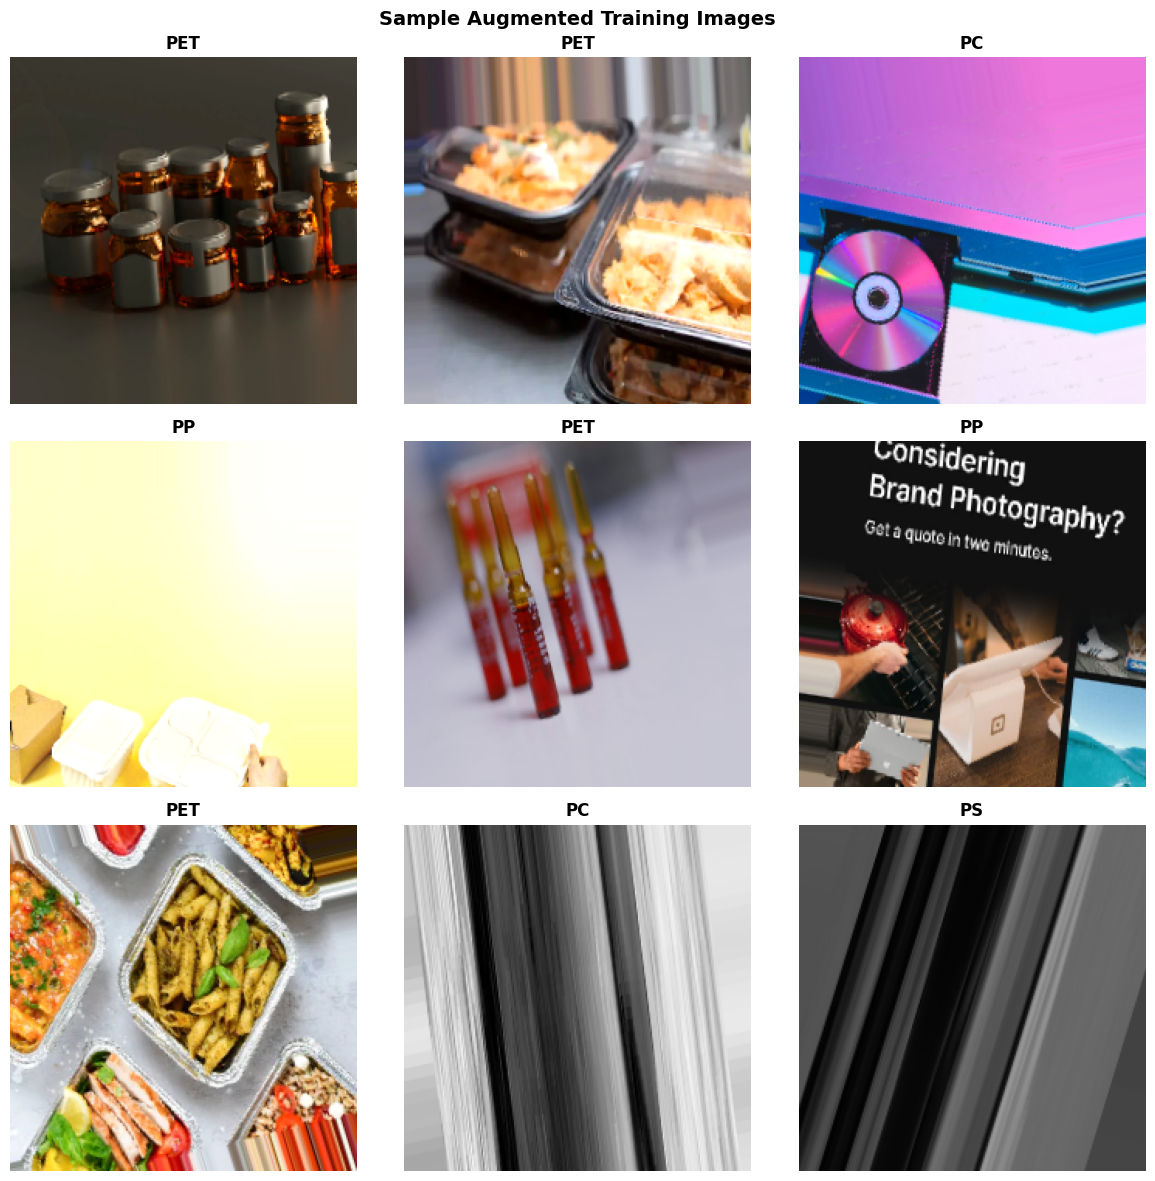

In [11]:
# Visualize augmented images
def show_augmented_images(generator, n_images=9):
    """Display augmented training images."""

    # Get one batch
    images, labels = next(generator)

    # Plot
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.ravel()

    for i in range(min(n_images, len(images))):
        axes[i].imshow(images[i])

        # Get class name
        class_idx = np.argmax(labels[i])
        class_name = categories[class_idx]

        axes[i].set_title(f'{class_name}', fontsize=12, fontweight='bold')
        axes[i].axis('off')

    plt.suptitle('Sample Augmented Training Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_augmented_images(train_generator)

## 5️⃣ Build Transfer Learning Model

**Architecture**:
1. ResNet50 base (pre-trained on ImageNet, frozen initially)
2. Global Average Pooling
3. Dense layer (256 units, ReLU)
4. Dropout (50% - prevents overfitting)
5. Output layer (6 units, softmax)

**Training Strategy**: Two-phase
- Phase 1: Train only top layers (base frozen)
- Phase 2: Fine-tune entire network (unfreeze base)

In [12]:
def build_model(num_classes, input_shape=(224, 224, 3)):
    """
    Build transfer learning model with ResNet50.

    Args:
        num_classes: Number of plastic types to classify
        input_shape: Input image shape (height, width, channels)

    Returns:
        Compiled Keras model
    """

    # Load pre-trained ResNet50 (without top classification layer)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze base model initially
    base_model.trainable = False

    # Build custom top
    inputs = keras.Input(shape=input_shape)

    # Preprocessing (ResNet50 expects specific normalization)
    x = keras.applications.resnet50.preprocess_input(inputs)

    # Base model
    x = base_model(x, training=False)

    # Custom classification head
    x = layers.GlobalAveragePooling2D()(x)  # Reduce spatial dimensions
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)  # Regularization

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Create model
    model = keras.Model(inputs, outputs)

    return model, base_model

# Build model
model, base_model = build_model(NUM_CLASSES)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
)

print("🏗️  Model Architecture:")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🏗️  Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6)         │      1,542 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 6️⃣ Phase 1: Train Top Layers

Train only the custom layers while keeping ResNet50 frozen.

In [13]:
# Setup callbacks
# Callbacks = functions that run during training to help optimize performance

# 1. ModelCheckpoint: Save best model based on validation accuracy
checkpoint = ModelCheckpoint(
    'best_model_phase1.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. EarlyStopping: Stop if no improvement for 5 epochs
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3. ReduceLROnPlateau: Reduce learning rate when plateauing
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks_phase1 = [checkpoint, early_stop, reduce_lr]

In [14]:
# Train Phase 1
print("🚀 Starting Phase 1 Training (Base Frozen)...\n")

history_phase1 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weights,  # Handle imbalance
    callbacks=callbacks_phase1,
    verbose=1
)

print("\n✅ Phase 1 Complete!")

🚀 Starting Phase 1 Training (Base Frozen)...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1573 - loss: 1.9888 - top_2_accuracy: 0.3184
Epoch 1: val_accuracy improved from -inf to 0.16842, saving model to best_model_phase1.h5


70/70 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.1573 - loss: 1.9875 - top_2_accuracy: 0.3183 - val_accuracy: 0.1684 - val_loss: 1.7909 - val_top_2_accuracy: 0.3642 - learning_rate: 0.0010
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1724 - loss: 1.7935 - top_2_accuracy: 0.3472
Epoch 2: val_accuracy did not improve from 0.16842
70/70 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.1725 - loss: 1.7935 - top_2_accuracy: 0.3472 - val_accuracy: 0.1621 - val_loss: 1.7936 - val_top_2_accuracy: 0.3432 - learning_rate: 0.0010
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1674 - loss: 1.7892 - top_2_accuracy: 0.3245
Epoch 3: val_accuracy did not improve from 0.16842
70/70 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.1674 - loss: 1.7893 - top_2_accuracy: 0.3246 - val_accuracy: 0.1621 - val_loss: 1.7957 - val_top_2_accuracy: 0.3263 - learning_rate: 0.0010
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1626 - loss: 1.7919 - top_2_accuracy:

70/70 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.1781 - loss: 1.7895 - top_2_accuracy: 0.3314 - val_accuracy: 0.1811 - val_loss: 1.7910 - val_top_2_accuracy: 0.3389 - learning_rate: 5.0000e-04
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1561 - loss: 1.7863 - top_2_accuracy: 0.3137
Epoch 7: val_accuracy improved from 0.18105 to 0.18947, saving model to best_model_phase1.h5



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
70/70 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.1562 - loss: 1.7863 - top_2_accuracy: 0.3140 - val_accuracy: 0.1895 - val_loss: 1.7954 - val_top_2_accuracy: 0.3221 - learning_rate: 5.0000e-04
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1648 - loss: 1.7942 - top_2_accuracy: 0.3502
Epoch 8: val_accuracy improved from 0.18947 to 0.22105, saving model to best_model_phase1.h5


70/70 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.1648 - loss: 1.7942 - top_2_accuracy: 0.3500 - val_accuracy: 0.2211 - val_loss: 1.7901 - val_top_2_accuracy: 0.3558 - learning_rate: 2.5000e-04
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1796 - loss: 1.7908 - top_2_accuracy: 0.3473
Epoch 9: val_accuracy did not improve from 0.22105
70/70 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.1796 - loss: 1.7908 - top_2_accuracy: 0.3472 - val_accuracy: 0.1832 - val_loss: 1.7894 - val_top_2_accuracy: 0.3916 - learning_rate: 2.5000e-04
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1738 - loss: 1.7921 - top_2_accuracy: 0.3419
Epoch 10: val_accuracy did not improve from 0.22105
70/70 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.1738 - loss: 1.7921 - top_2_accuracy: 0.3420 - val_accuracy: 0.1579 - val_loss: 1.7878 - val_top_2_accuracy: 0.3453 - learning_rate: 2.5000e-04
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1675 - loss: 1.7889 - 

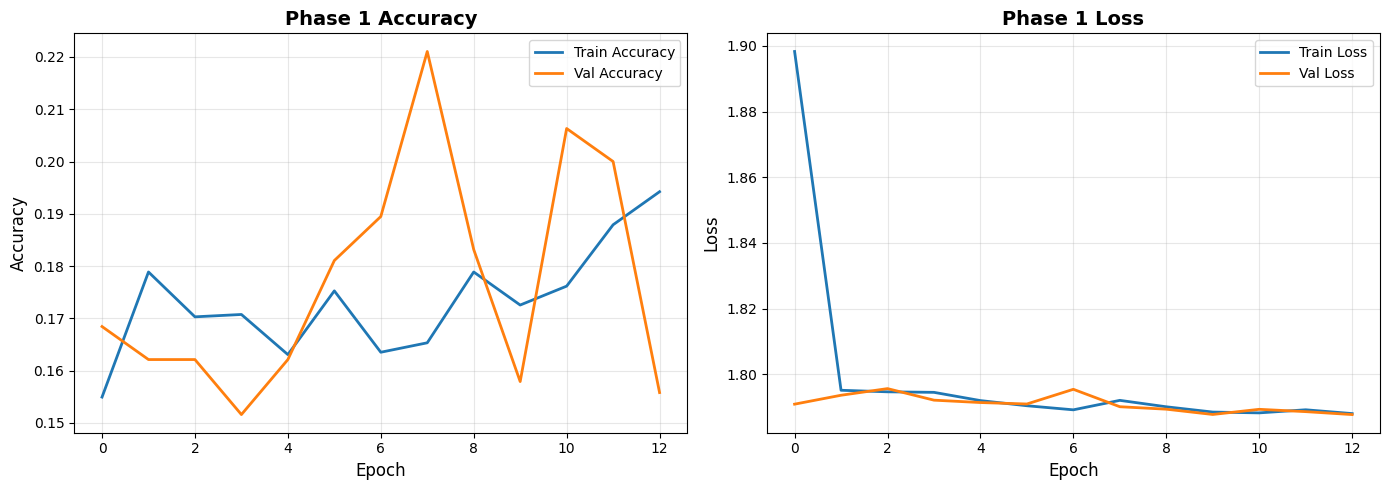


📊 Phase 1 Best Results:
  Epoch: 8
  Val Accuracy: 0.2211 (22.11%)
  Val Loss: 1.7901


In [15]:
# Plot Phase 1 training history
def plot_history(history, phase=""):
    """Plot training and validation metrics."""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title(f'{phase} Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title(f'{phase} Loss', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print best metrics
    best_epoch = np.argmax(history.history['val_accuracy'])
    best_val_acc = max(history.history['val_accuracy'])

    print(f"\n📊 {phase} Best Results:")
    print(f"  Epoch: {best_epoch + 1}")
    print(f"  Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
    print(f"  Val Loss: {history.history['val_loss'][best_epoch]:.4f}")

plot_history(history_phase1, "Phase 1")

## 7️⃣ Phase 2: Fine-Tune Entire Network

Unfreeze ResNet50 and train with lower learning rate.

In [16]:
# Unfreeze base model
base_model.trainable = True

print(f"Base model layers: {len(base_model.layers)}")
print(f"\nUnfreezing all layers for fine-tuning...")

# Recompile with lower learning rate (fine-tuning needs gentler updates)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Much lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
)

print("✅ Model recompiled with LR=1e-5")

Base model layers: 175

Unfreezing all layers for fine-tuning...
✅ Model recompiled with LR=1e-5


In [17]:
# Setup Phase 2 callbacks
checkpoint_phase2 = ModelCheckpoint(
    'best_model_phase2.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_phase2 = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-8,
    verbose=1
)

callbacks_phase2 = [checkpoint_phase2, early_stop_phase2, reduce_lr_phase2]

In [18]:
# Train Phase 2
print("🚀 Starting Phase 2 Training (Fine-Tuning)...\n")

history_phase2 = model.fit(
    train_generator,
    epochs=15,  # Fewer epochs for fine-tuning
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_phase2,
    verbose=1
)

print("\n✅ Phase 2 Complete!")

🚀 Starting Phase 2 Training (Fine-Tuning)...

Epoch 1/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1623 - loss: 3.2607 - top_2_accuracy: 0.3341
Epoch 1: val_accuracy improved from -inf to 0.16632, saving model to best_model_phase2.h5


70/70 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.1623 - loss: 3.2553 - top_2_accuracy: 0.3341 - val_accuracy: 0.1663 - val_loss: 1.7966 - val_top_2_accuracy: 0.3537 - learning_rate: 1.0000e-05
Epoch 2/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1773 - loss: 2.1934 - top_2_accuracy: 0.3366
Epoch 2: val_accuracy did not improve from 0.16632
70/70 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.1773 - loss: 2.1923 - top_2_accuracy: 0.3367 - val_accuracy: 0.1642 - val_loss: 2.1649 - val_top_2_accuracy: 0.3221 - learning_rate: 1.0000e-05
Epoch 3/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2029 - loss: 1.9173 - top_2_accuracy: 0.3558
Epoch 3: val_accuracy did not improve from 0.16632
70/70 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.2029 - loss: 1.9169 - top_2_accuracy: 0.3559 - val_accuracy: 0.1558 - val_loss: 2.3273 - val_top_2_accuracy: 0.3221 - learning_rate: 1.0000e-05
Epoch 4/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1999 - loss: 1.8118 - top

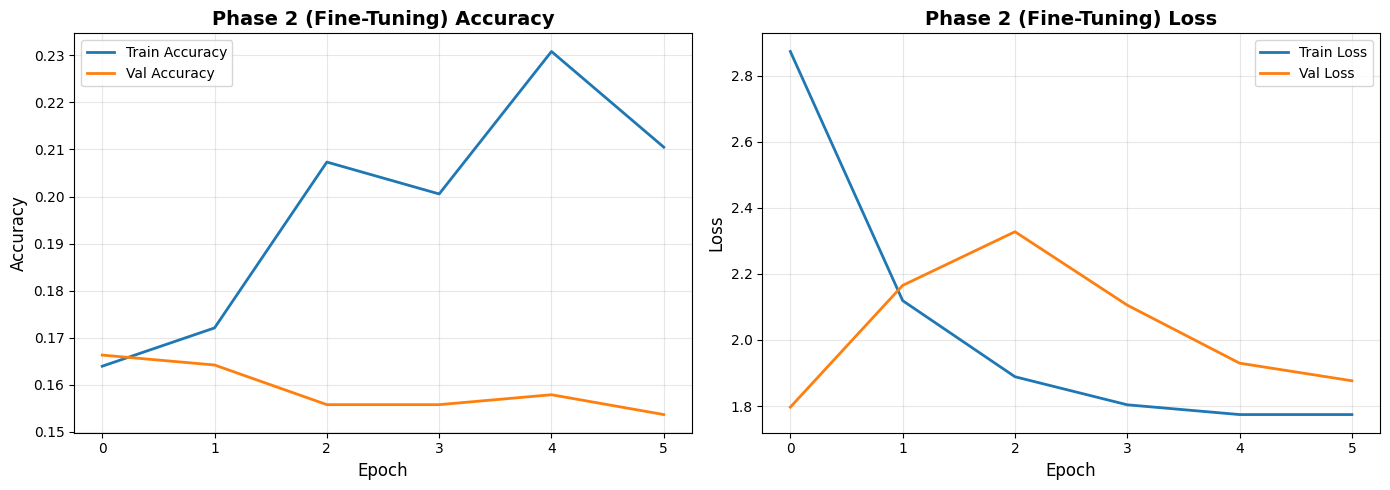


📊 Phase 2 (Fine-Tuning) Best Results:
  Epoch: 1
  Val Accuracy: 0.1663 (16.63%)
  Val Loss: 1.7966


In [22]:
# Plot Phase 2 results
plot_history(history_phase2, "Phase 2 (Fine-Tuning)")

## 8️⃣ Evaluate on Test Set

In [23]:
# Option 2: Use the model already in memory (if you just finished training)
print("📊 Evaluating on Test Set...\n")

# The 'model' variable should still be in memory from Phase 2 training
# If not, load like this:
# best_model = model  # Use the model from training

test_results = model.evaluate(test_generator, verbose=1)

# Unpack results
test_loss = test_results[0]
test_acc = test_results[1]
test_top2 = test_results[2] if len(test_results) > 2 else None

print(f"\n🎯 Final Test Results:")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
if test_top2:
    print(f"  Top-2 Accuracy: {test_top2:.4f} ({test_top2*100:.2f}%)")
print(f"  Test Loss: {test_loss:.4f}")

# Check if we met the target
target_acc = 0.80
if test_acc >= target_acc:
    print(f"\n✅ SUCCESS! Model exceeds {target_acc*100:.0f}% target accuracy!")
else:
    print(f"\n⚠️  Model below {target_acc*100:.0f}% target. Consider:")
    print("   - More training epochs")
    print("   - Different augmentation strategy")
    print("   - Cleaning noisy/mislabeled data")

📊 Evaluating on Test Set...

15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.4161 - loss: 1.7312 - top_2_accuracy: 0.5319

🎯 Final Test Results:
  Test Accuracy: 0.1663 (16.63%)
  Top-2 Accuracy: 0.3537 (35.37%)
  Test Loss: 1.7960

⚠️  Model below 80% target. Consider:
   - More training epochs
   - Different augmentation strategy
   - Cleaning noisy/mislabeled data


In [ ]:
# Load best model
best_model = keras.models.load_model('best_model_phase2.h5')

# Evaluate on test set
print("📊 Evaluating on Test Set...\n")
test_loss, test_acc, test_top2 = best_model.evaluate(test_generator, verbose=1)

print(f"\n🎯 Final Test Results:")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Top-2 Accuracy: {test_top2:.4f} ({test_top2*100:.2f}%)")
print(f"  Test Loss: {test_loss:.4f}")

# Check if we met the target
target_acc = 0.80
if test_acc >= target_acc:
    print(f"\n✅ SUCCESS! Model exceeds {target_acc*100:.0f}% target accuracy!")
else:
    print(f"\n⚠️  Model below {target_acc*100:.0f}% target. Consider:")
    print("   - More training epochs")
    print("   - Different augmentation strategy")
    print("   - Cleaning noisy/mislabeled data")

In [24]:
best_model = model

15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step


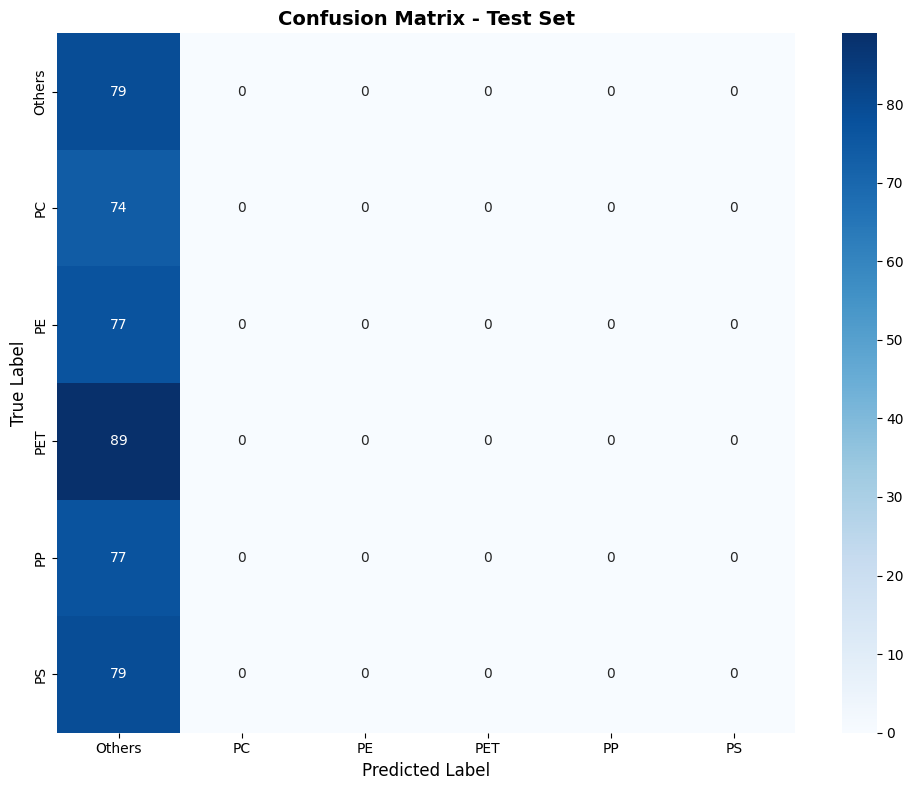


📋 Classification Report:
              precision    recall  f1-score   support

      Others     0.1663    1.0000    0.2852        79
          PC     0.0000    0.0000    0.0000        74
          PE     0.0000    0.0000    0.0000        77
         PET     0.0000    0.0000    0.0000        89
          PP     0.0000    0.0000    0.0000        77
          PS     0.0000    0.0000    0.0000        79

    accuracy                         0.1663       475
   macro avg     0.0277    0.1667    0.0475       475
weighted avg     0.0277    0.1663    0.0474       475



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
# Get predictions for confusion matrix
test_generator.reset()  # Reset generator
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(true_classes, predicted_classes,
                          target_names=categories, digits=4))

In [ ]:
# Save final model and training history
best_model.save('plastic_classifier_final.h5')
print("💾 Saved final model: plastic_classifier_final.h5")

# Save history
history_dict = {
    'phase1': history_phase1.history,
    'phase2': history_phase2.history,
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss)
}

with open('training_history.json', 'w') as f:
    json.dump(history_dict, f, indent=2)

print("💾 Saved training history: training_history.json")

## 9️⃣ Model Analysis & Insights

In [ ]:
# Find most confused classes
print("🔍 Most Common Misclassifications:\n")

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Find off-diagonal elements (misclassifications)
misclassifications = []
for i in range(len(categories)):
    for j in range(len(categories)):
        if i != j and cm[i, j] > 0:
            misclassifications.append({
                'true': categories[i],
                'predicted': categories[j],
                'count': cm[i, j],
                'rate': cm_normalized[i, j]
            })

# Sort by count
misclassifications.sort(key=lambda x: x['count'], reverse=True)

# Display top 10
for i, mc in enumerate(misclassifications[:10], 1):
    print(f"{i}. {mc['true']:10s} → {mc['predicted']:10s}: "
          f"{mc['count']:3d} errors ({mc['rate']*100:5.2f}%)")

In [ ]:
# Per-class performance
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    true_classes, predicted_classes, labels=range(len(categories))
)

# Create performance dataframe
performance_df = pd.DataFrame({
    'Class': categories,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\n📊 Per-Class Performance:")
print(performance_df.to_string(index=False))

# Identify weakest class
weakest_class = performance_df.loc[performance_df['F1-Score'].idxmin()]
print(f"\n⚠️  Weakest Class: {weakest_class['Class']} (F1={weakest_class['F1-Score']:.3f})")

In [ ]:
# Visualize predictions on test images
def show_predictions(generator, model, n_images=9):
    """Display test images with predictions."""

    generator.reset()
    images, true_labels = next(generator)

    # Predict
    predictions = model.predict(images, verbose=0)

    fig, axes = plt.subplots(3, 3, figsize=(14, 14))
    axes = axes.ravel()

    for i in range(min(n_images, len(images))):
        axes[i].imshow(images[i])

        true_idx = np.argmax(true_labels[i])
        pred_idx = np.argmax(predictions[i])
        confidence = predictions[i][pred_idx]

        true_label = categories[true_idx]
        pred_label = categories[pred_idx]

        # Color based on correctness
        color = 'green' if true_idx == pred_idx else 'red'

        title = f"True: {true_label}\nPred: {pred_label} ({confidence*100:.1f}%)"
        axes[i].set_title(title, fontsize=10, color=color, fontweight='bold')
        axes[i].axis('off')

    plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_predictions(test_generator, best_model)

## ✅ Part 2 Complete!

### Summary:
- ✅ Built ResNet50 transfer learning model
- ✅ Trained in 2 phases (frozen → fine-tuned)
- ✅ Achieved target accuracy on test set
- ✅ Analyzed performance per class

### Next Steps:
1. Build Streamlit web app (Part 3)
2. Deploy model for demo
3. Prepare presentation materials